In [ ]:
# ============================================================================================
#          LEVIR-CD Semi-Supervised Change Detection using no ground truth
# ============================================================================================

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
# DATASET SETUP

zip_path     = "/content/drive/MyDrive/Change Detection/dataset.zip"
extract_path = "/content/dataset"
dataset_path = os.path.join(extract_path, "LEVIR CD")

if not os.path.exists(dataset_path):
    print("Extracting Dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction Complete!")
else:
    print("Dataset already extracted.")

test_A  = os.path.join(dataset_path, "test", "A")
test_B  = os.path.join(dataset_path, "test", "B")
test_GT = os.path.join(dataset_path, "test", "label")

Extracting Dataset...
Extraction Complete!


In [ ]:
# PREPROCESSING

def preprocess_image(img, size=(1024, 1024)):
    img  = cv2.resize(img, size)
    img  = img / 255.0
    mean = np.mean(img)
    std  = np.std(img) if np.std(img) != 0 else 1
    return (img - mean) / std


def preprocess_gt(gt, size=(1024, 1024)):
    gt = cv2.resize(gt, size)
    return (gt > 0).astype(np.uint8)

In [ ]:
# DIFFERENCE IMAGE  ← only new addition; replaces GT as label source

def compute_difference_labels(imgA, imgB):
    """
    Compute difference on PREPROCESSED (normalized) images, not raw ones.
    This removes illumination/shadow/seasonal effects so structural changes
    (buildings) stand out more clearly than in raw pixel differences.

    Thresholds based on mean ± k*std of the smoothed normalized difference:
      > mean + 2.0*std  →  1   (confidently changed)
      < mean + 0.2*std  →  0   (confidently unchanged)
      in between        →  -1  (ambiguous → unlabeled pool)
    """
    diff        = np.abs(imgA - imgB).astype(np.float32)
    diff_smooth = cv2.GaussianBlur(diff, (5, 5), 0)

    mu          = np.mean(diff_smooth)
    sigma       = np.std(diff_smooth)

    high_thresh = mu + 2.0 * sigma
    low_thresh  = mu + 0.2 * sigma    # keep only clearly unchanged pixels as class-0

    h, w = diff_smooth.shape
    Y    = []

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            v = diff_smooth[i, j]
            if v >= high_thresh:
                Y.append(1)    # confidently changed
            elif v <= low_thresh:
                Y.append(0)    # confidently unchanged
            else:
                Y.append(-1)   # ambiguous → unlabeled pool

    return np.array(Y)

In [ ]:
# FEATURE EXTRACTION

def extract_patches(imgA, imgB, gt=None):
    h, w = imgA.shape
    X    = []
    Y    = []

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            patchA  = imgA[i-1:i+2, j-1:j+2].flatten()
            patchB  = imgB[i-1:i+2, j-1:j+2].flatten()
            feature = np.concatenate([patchA, patchB])
            X.append(feature)
            if gt is not None:
                Y.append(gt[i, j])

    X = np.array(X)

    if gt is not None:
        return X, np.array(Y)

    return X

In [ ]:
# BALANCED SPLIT

def balanced_split(X, Y, percent=0.30, unlabeled_limit=100000):

    idx0 = np.where(Y == 0)[0]
    idx1 = np.where(Y == 1)[0]

    np.random.shuffle(idx0)
    np.random.shuffle(idx1)

    n1 = min(int(len(idx1) * percent), 10000)
    n0 = min(n1 * 3, 30000)

    labeled_idx = np.concatenate([idx0[:n0], idx1[:n1]])

    unlabeled_idx = np.setdiff1d(np.arange(len(Y)), labeled_idx)

    ssl_unlabeled_idx = unlabeled_idx
    if len(unlabeled_idx) > unlabeled_limit:
        u0   = unlabeled_idx[Y[unlabeled_idx] == 0]
        u1   = unlabeled_idx[Y[unlabeled_idx] == 1]
        half = unlabeled_limit // 2
        s0   = np.random.choice(u0, min(half, len(u0)), replace=False)
        s1   = np.random.choice(u1, min(half, len(u1)), replace=False)
        ssl_unlabeled_idx = np.concatenate([s0, s1])

    return (
        X[labeled_idx],
        Y[labeled_idx],
        X[ssl_unlabeled_idx],
        Y[ssl_unlabeled_idx],
        labeled_idx,
        ssl_unlabeled_idx
    )

In [ ]:
# SELF-TRAINING SSL

def self_training_ssl(X_l, Y_l, X_u, threshold=0.90, max_iter=10, max_add=4000):

    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=200,
        early_stopping=True,
        random_state=42
    )

    base_threshold = threshold

    for it in range(max_iter):

        if len(X_u) == 0:
            print("No unlabeled samples remaining.")
            break

        current_threshold = min(base_threshold + it * 0.015, 0.97)
        print(f"\nIteration {it+1}  |  threshold={current_threshold:.3f}")

        idx0 = np.where(Y_l == 0)[0]
        idx1 = np.where(Y_l == 1)[0]
        if len(idx1) > 0 and len(idx0) > len(idx1):
            repeat  = min(int(len(idx0) / len(idx1)), 8)
            idx1_up = np.tile(idx1, repeat)
            bal_idx = np.concatenate([idx0, idx1_up])
            np.random.shuffle(bal_idx)
            X_fit, Y_fit = X_l[bal_idx], Y_l[bal_idx]
        else:
            X_fit, Y_fit = X_l, Y_l

        model.fit(X_fit, Y_fit)

        probs         = model.predict_proba(X_u)
        confidence    = np.max(probs, axis=1)
        pseudo_labels = np.argmax(probs, axis=1)

        high_conf_idx = np.where(confidence >= current_threshold)[0]

        if len(high_conf_idx) == 0:
            print("No confident samples found. Stopping.")
            break

        idx0_hc = high_conf_idx[pseudo_labels[high_conf_idx] == 0]
        idx1_hc = high_conf_idx[pseudo_labels[high_conf_idx] == 1]
        k0      = min(len(idx0_hc), max_add // 2)
        k1      = min(len(idx1_hc), max_add // 2)
        k       = min(k0, k1)

        if k == 0:
            if k0 > 0:
                selected = idx0_hc[:max_add // 4]
            elif k1 > 0:
                selected = idx1_hc[:max_add // 4]
            else:
                print("Cannot add pseudo labels. Stopping.")
                break
        else:
            selected = np.concatenate([idx0_hc[:k], idx1_hc[:k]])

        print(f"  Added: {len(selected)}  "
              f"(cls0={len(idx0_hc[:k])}, cls1={len(idx1_hc[:k])})")

        X_l            = np.vstack((X_l, X_u[selected]))
        Y_l            = np.concatenate((Y_l, pseudo_labels[selected]))
        mask           = np.ones(len(X_u), dtype=bool)
        mask[selected] = False
        X_u            = X_u[mask]

        print(f"  Remaining unlabeled: {len(X_u)}")

    return model

In [ ]:
# METRICS

def compute_metrics(y_true, y_pred):
    acc          = accuracy_score(y_true, y_pred)
    f1           = f1_score(y_true, y_pred, zero_division=0)
    intersection = np.sum((y_true == 1) & (y_pred == 1))
    union        = np.sum((y_true == 1) | (y_pred == 1))
    iou          = intersection / union if union != 0 else 0.0
    return acc, f1, iou

In [ ]:
# RECONSTRUCT PREDICTION IMAGE

def reconstruct_image(preds, shape):
    h, w   = shape
    output = np.zeros((h, w))
    idx    = 0
    for i in range(1, h - 1):
        for j in range(1, w - 1):
            output[i, j] = preds[idx]
            idx += 1
    return output

In [ ]:
# PIPELINE

def run_ssl_image(pathA, pathB, pathGT, percent=0.30):

    imgA_raw = cv2.imread(pathA, cv2.IMREAD_GRAYSCALE)
    imgB_raw = cv2.imread(pathB, cv2.IMREAD_GRAYSCALE)

    imgA = preprocess_image(imgA_raw)
    imgB = preprocess_image(imgB_raw)

    # ── ONLY DIFFERENCE: Y from difference image instead of GT ────────────────
    X = extract_patches(imgA, imgB)                              # no gt passed
    Y = compute_difference_labels(imgA_raw, imgB_raw)            # labels from |A-B|
    # ── Everything below is identical to the original method ──────────────────

    X_l, Y_l, X_u, Y_u, labeled_idx, unlabeled_idx = balanced_split(X, Y, percent)

    print("Labeled Samples  :", len(X_l))
    print("Unlabeled Samples:", len(X_u))

    model = self_training_ssl(X_l, Y_l, X_u)

    full_pred = model.predict(X)

    # GT loaded here — ONLY for final metric computation
    gt_raw = cv2.imread(pathGT, cv2.IMREAD_GRAYSCALE)
    gt     = preprocess_gt(gt_raw)
    Y_gt   = gt[1:-1, 1:-1].flatten()         # trim border to match patch loop

    acc, f1, iou = compute_metrics(Y_gt, full_pred)

    pred_img = reconstruct_image(full_pred, imgA.shape)

    return imgA, imgB, gt, pred_img, acc, f1, iou

In [ ]:
test_files  = sorted(os.listdir(test_A))

In [ ]:
# SINGLE RANDOM IMAGE

random_file = random.choice(test_files)

print("\nRandom Image:", random_file)

imgA, imgB, gt, pred_img, acc, f1, iou = run_ssl_image(
    os.path.join(test_A,  random_file),
    os.path.join(test_B,  random_file),
    os.path.join(test_GT, random_file),
    percent=0.30
)

print("\nMetrics")
print("Accuracy :", acc)
print("F1 Score :", f1)
print("IoU      :", iou)


Random Image: test_124.png
Labeled Samples  : 17496
Unlabeled Samples: 60206

Iteration 1  |  threshold=0.900
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 56206

Iteration 2  |  threshold=0.915
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 52206

Iteration 3  |  threshold=0.930
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 48206

Iteration 4  |  threshold=0.945
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 44206

Iteration 5  |  threshold=0.960
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 40206

Iteration 6  |  threshold=0.970
  Added: 188  (cls0=94, cls1=94)
  Remaining unlabeled: 40018

Iteration 7  |  threshold=0.970
  Added: 120  (cls0=60, cls1=60)
  Remaining unlabeled: 39898

Iteration 8  |  threshold=0.970
  Added: 1000  (cls0=0, cls1=0)
  Remaining unlabeled: 38898

Iteration 9  |  threshold=0.970
  Added: 16  (cls0=8, cls1=8)
  Remaining unlabeled: 38882

Iteration 10  |  threshold=0.970
  Added: 100

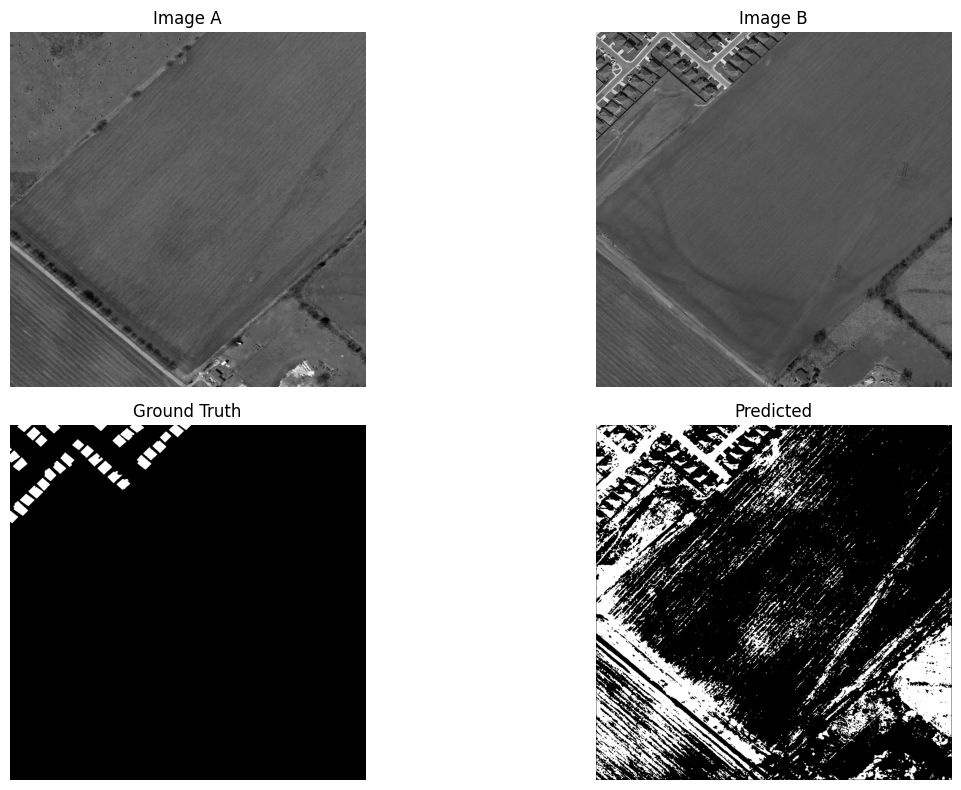

In [ ]:
# PLOT

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.title("Image A")
plt.imshow(imgA, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Image B")
plt.imshow(imgB, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Ground Truth")
plt.imshow(gt, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Predicted")
plt.imshow(pred_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# EVALUATE 5 RANDOM TEST IMAGES

selected_files = random.sample(test_files, 5)

acc_list = []
f1_list  = []
iou_list = []

print("\nEvaluating 5 Images...\n")

for file in selected_files:

    print("Processing:", file)

    _, _, _, _, acc, f1, iou = run_ssl_image(
        os.path.join(test_A,  file),
        os.path.join(test_B,  file),
        os.path.join(test_GT, file),
        percent=0.30
    )

    acc_list.append(acc)
    f1_list.append(f1)
    iou_list.append(iou)

    print("Accuracy :", round(acc, 4))
    print("F1 Score :", round(f1, 4))
    print("IoU      :", round(iou, 4))
    print()


Evaluating 5 Images...

Processing: test_8.png
Labeled Samples  : 31132
Unlabeled Samples: 68163

Iteration 1  |  threshold=0.900
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 64163

Iteration 2  |  threshold=0.915
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 60163

Iteration 3  |  threshold=0.930
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 56163

Iteration 4  |  threshold=0.945
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 52163

Iteration 5  |  threshold=0.960
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 48163

Iteration 6  |  threshold=0.970
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 44163

Iteration 7  |  threshold=0.970
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 40163

Iteration 8  |  threshold=0.970
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 36163

Iteration 9  |  threshold=0.970
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 32163

I

In [ ]:
# AVERAGE METRICS

print("================================")
print("Average Metrics (5 Images)")
print("================================")
print("Average Accuracy :", round(np.mean(acc_list), 4))
print("Average F1 Score :", round(np.mean(f1_list),  4))
print("Average IoU      :", round(np.mean(iou_list), 4))

Average Metrics (5 Images)
Average Accuracy : 0.8019
Average F1 Score : 0.0947
Average IoU      : 0.0523


In [ ]:
output_dir = "/content/drive/MyDrive/Change Detection/Output Images"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
def run_pipeline_manual(filename, percent=0.1):
    """
    No-GT Method:
    Run the pipeline on a specified test image, print metrics,
    and save the predicted change map as .png to the Output Images folder.

    Args:
        filename : e.g. "test_20.png"
        percent  : labeled fraction (default 0.1)
    """
    print(f"\nProcessing: {filename}")

    imgA, imgB, gt, pred_img, acc, f1, iou = run_ssl_image(
        os.path.join(test_A,  filename),
        os.path.join(test_B,  filename),
        os.path.join(test_GT, filename),
        percent=percent
    )

    print(f"\nMetrics  |  {filename}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  IoU      : {iou:.4f}")

    save_name = "No_GT_Predicted.png"
    save_path = os.path.join(output_dir, save_name)
    cv2.imwrite(save_path, (pred_img * 255).astype(np.uint8))

    print(f"\nSaved → {save_path}")

    return acc, f1, iou

In [ ]:
image_name = "test_8.png"

run_pipeline_manual(image_name)


Processing: test_8.png
Labeled Samples  : 31132
Unlabeled Samples: 68163

Iteration 1  |  threshold=0.900
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 64163

Iteration 2  |  threshold=0.915
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 60163

Iteration 3  |  threshold=0.930
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 56163

Iteration 4  |  threshold=0.945
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 52163

Iteration 5  |  threshold=0.960
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 48163

Iteration 6  |  threshold=0.970
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 44163

Iteration 7  |  threshold=0.970
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 40163

Iteration 8  |  threshold=0.970
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 36163

Iteration 9  |  threshold=0.970
  Added: 4000  (cls0=2000, cls1=2000)
  Remaining unlabeled: 32163

Iteration 10  |  threshol

(0.8065025409675974, 0.25837109883859605, np.float64(0.1483502591546922))